In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns #type: ignore
import os
import json

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pickle
from datetime import datetime
import warnings
import traceback
import sys

import xgboost as xgb #type: ignore
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from datetime import timedelta

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from helpFolder import *

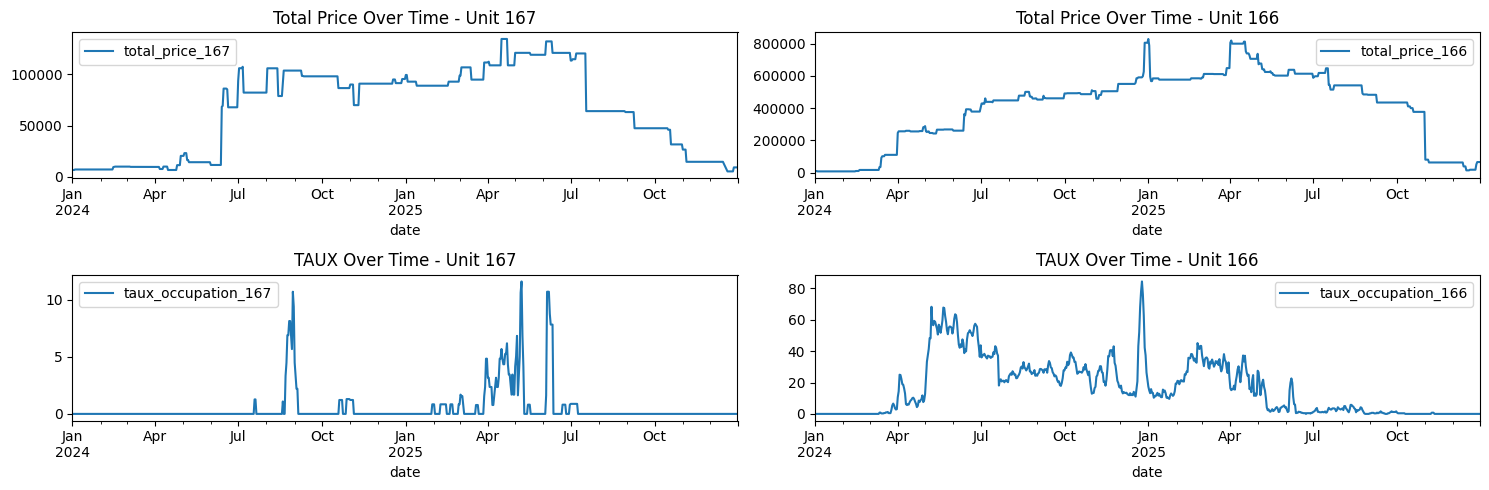

In [2]:
df_167, df_166 = prepare_and_plot_data('../../Data/UnitsFinalCSVData/FinalCSVdata.csv', 
                                       '2024-06-15', '2025-07-15')

--- Starting XGBoost Pipeline for Unit 166 ---
Target type: taux

[Step 1/3] Splitting data with test_size=0.3...
Split complete. Test size: 0.30
Target column: taux_occupation_166
Training set range: 2024-06-15 00:00:00 to 2025-03-18 00:00:00 (277 samples)
Testing set range: 2025-03-19 00:00:00 to 2025-07-15 00:00:00 (119 samples)

[Step 2/3] Training and evaluating XGBoost model...

Training XGBoost model for target: taux_occupation_166
Hyperparameters: n_estimators=3000, lr=0.01, max_depth=20
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Training set size: 277 samples
Testing set size: 119 samples

Starting Training...
Training Finished.

Model Evaluation Metrics:
Train RMSE: 0.00
Test RMSE: 26.61
Train MAE: 0.00
Test MAE: 23.07
Train R²: 1.0000
Test R²: -4.0330

Feature Importance:
           Feature  Importance
5  total_price_166    0.372019
4       weekofyear    0.268327
2             year    0.148040
3        dayofyear    0.11759

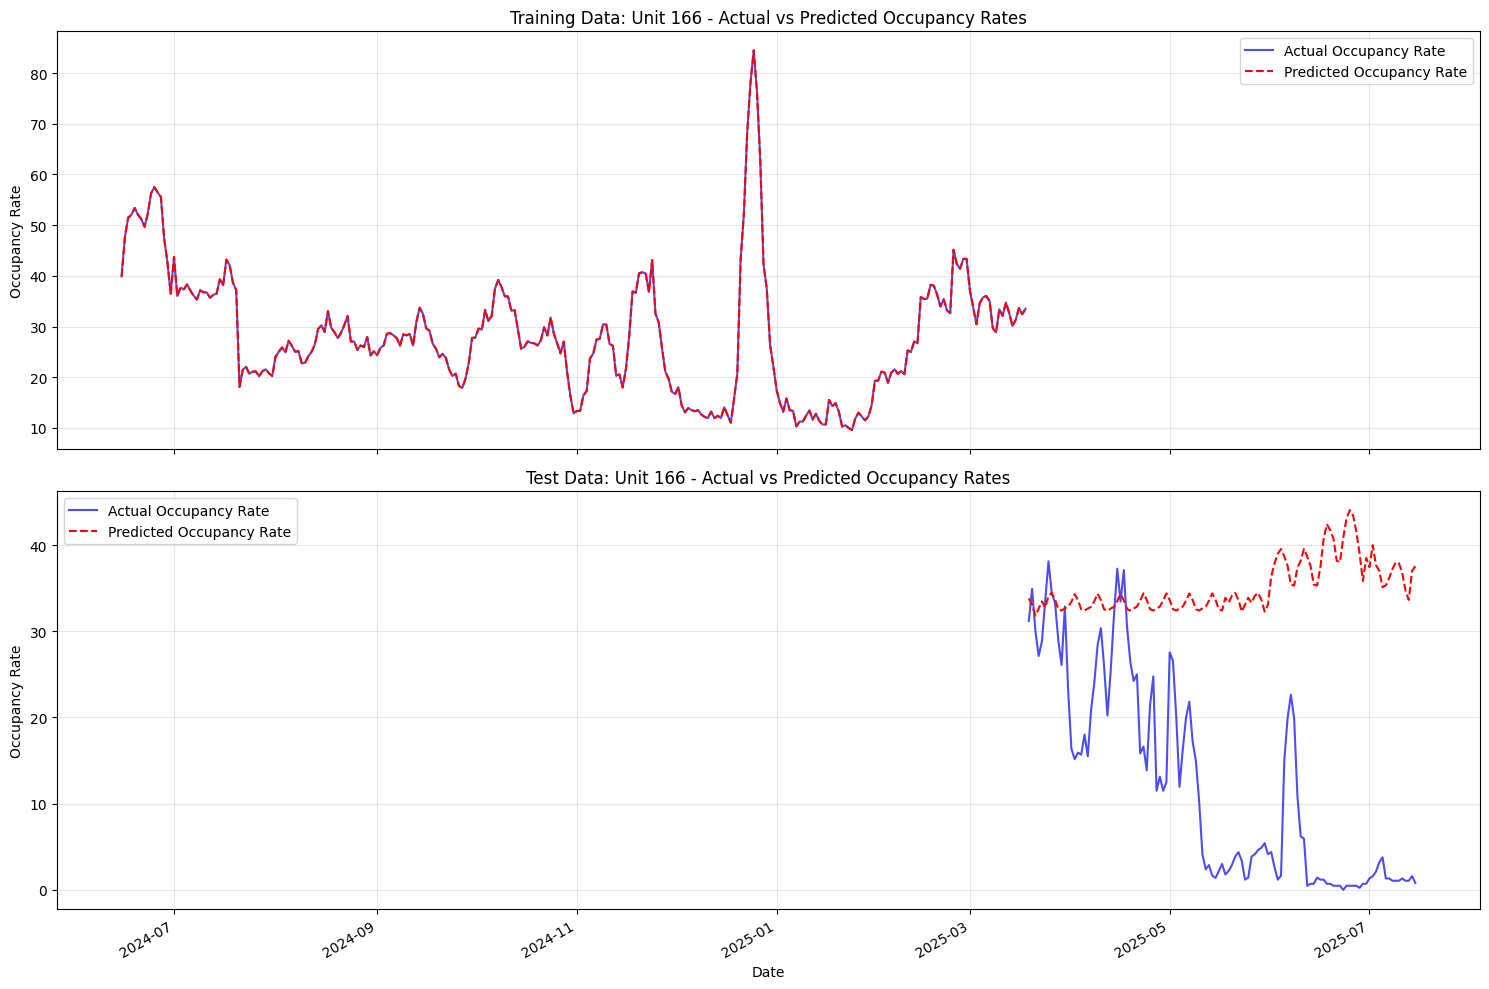

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Target column: taux_occupation_166


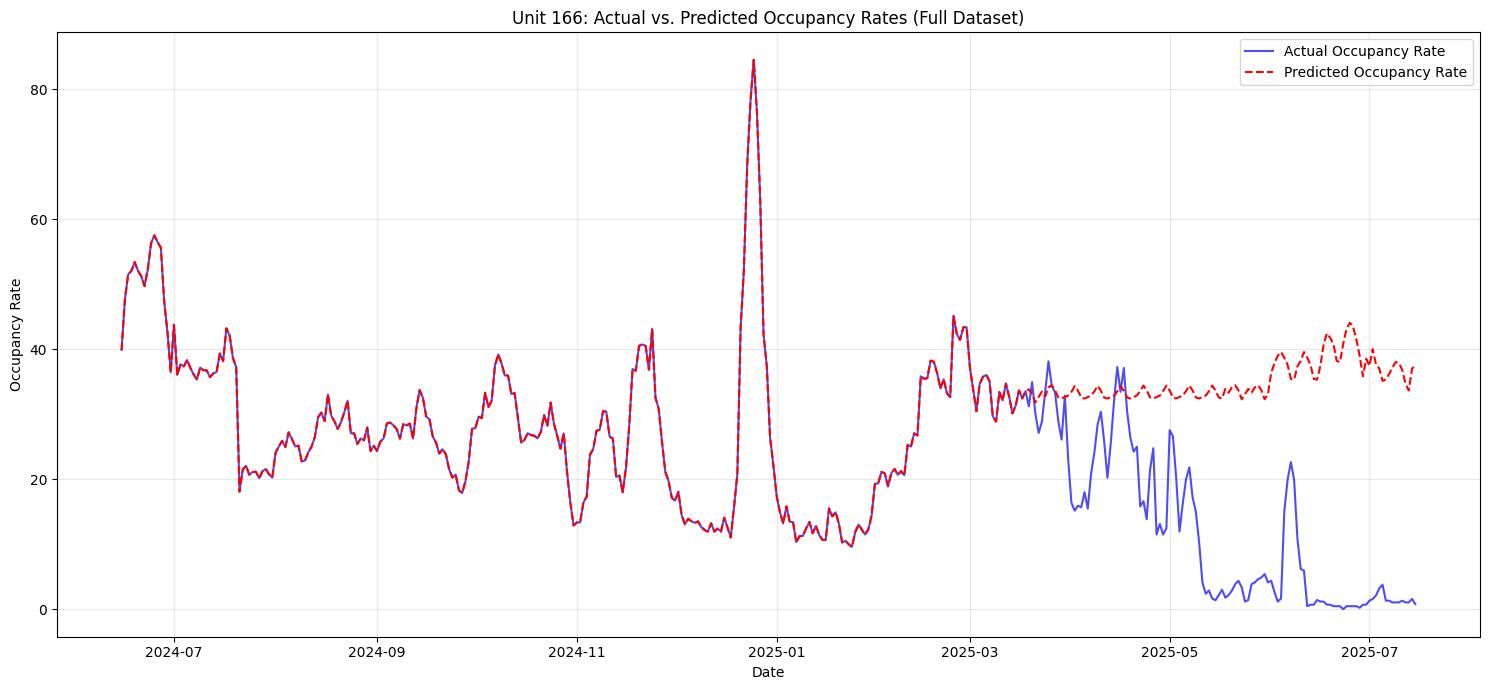


Pipeline finished for Unit 166 (target: taux).
--- End XGBoost Pipeline ---


In [3]:
xgb_results_taux_166 = run_xgboost_pipeline(
    df_166,
    '166',
    test_size=0.3,
    target_type='taux',
    n_estimators=3000,
    max_depth=20,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
)

--- Starting XGBoost Pipeline for Unit 167 ---
Target type: taux

[Step 1/3] Splitting data with test_size=0.1...
Split complete. Test size: 0.10
Target column: taux_occupation_167
Training set range: 2024-06-15 00:00:00 to 2025-06-05 00:00:00 (356 samples)
Testing set range: 2025-06-06 00:00:00 to 2025-07-15 00:00:00 (40 samples)

[Step 2/3] Training and evaluating XGBoost model...

Training XGBoost model for target: taux_occupation_167
Hyperparameters: n_estimators=3000, lr=0.01, max_depth=20
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_167']
Training set size: 356 samples
Testing set size: 40 samples

Starting Training...
Training Finished.

Model Evaluation Metrics:
Train RMSE: 0.00
Test RMSE: 2.25
Train MAE: 0.00
Test MAE: 2.01
Train R²: 1.0000
Test R²: 0.4877

Feature Importance:
           Feature  Importance
5  total_price_167    0.510587
3        dayofyear    0.151878
4       weekofyear    0.141727
2             year    0.092251
1  

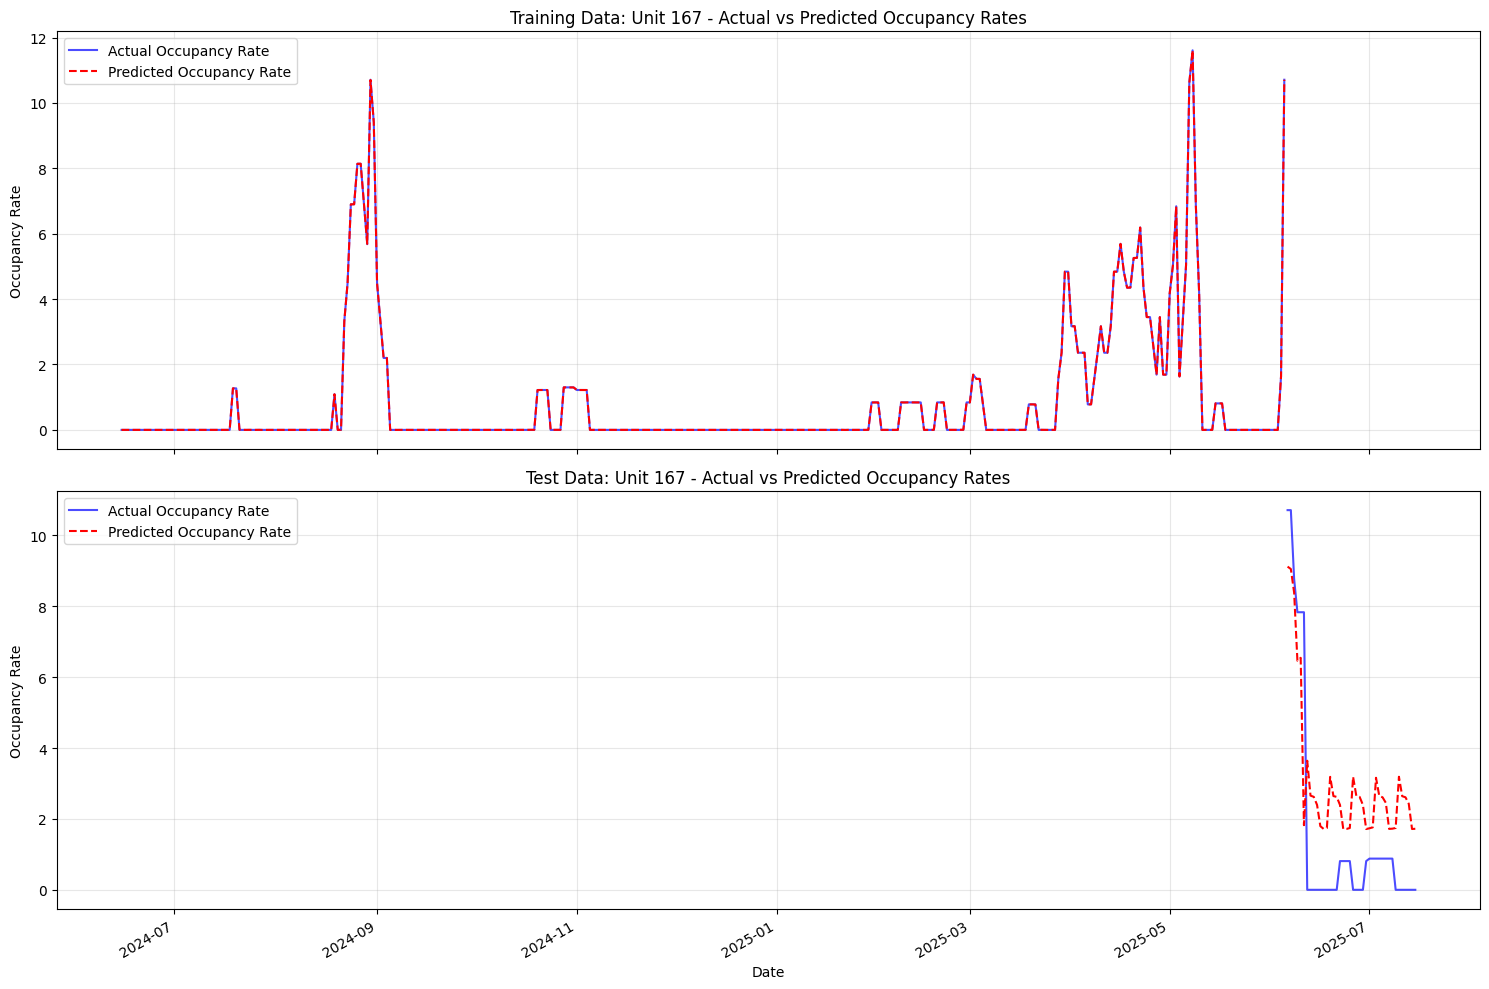

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_167']
Target column: taux_occupation_167


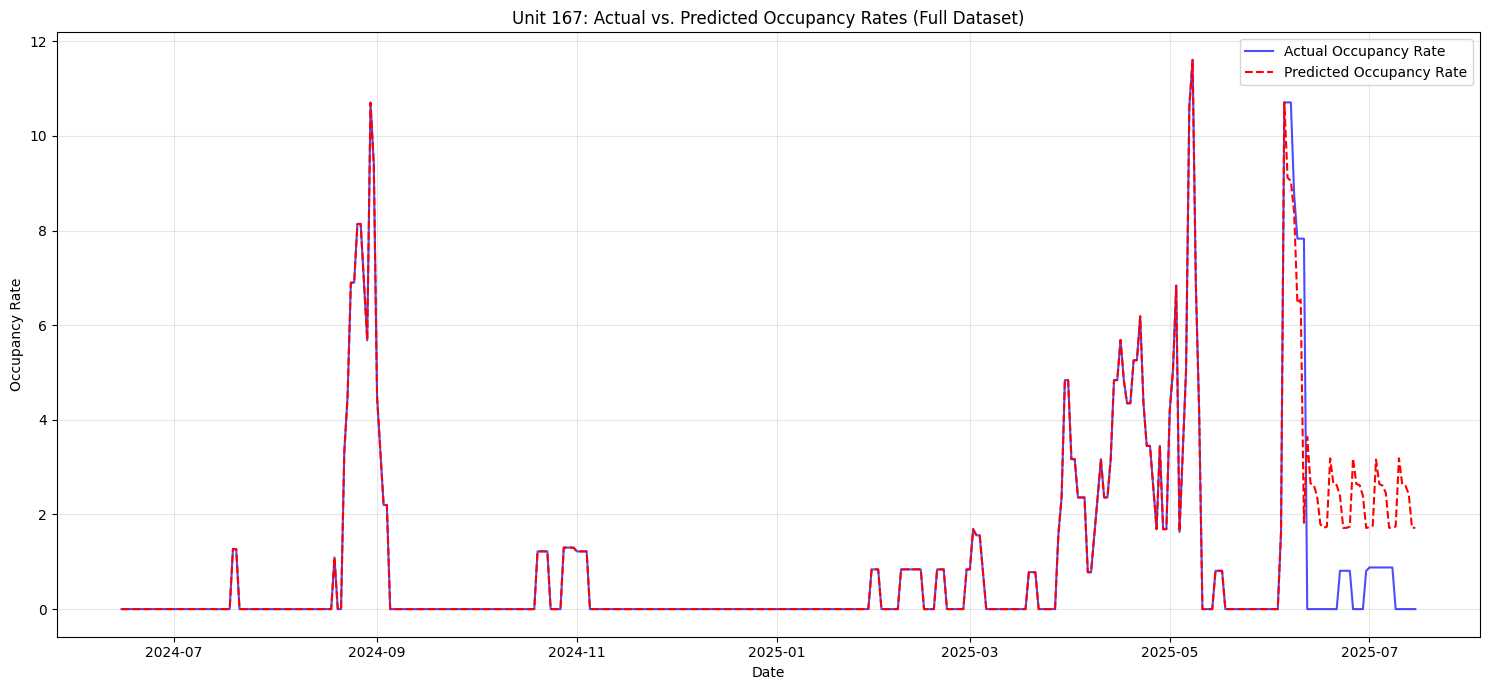


Pipeline finished for Unit 167 (target: taux).
--- End XGBoost Pipeline ---


In [4]:
xgb_results_taux_167 = run_xgboost_pipeline(
    df_167,
    '167',
    test_size=0.1,
    target_type='taux',
    n_estimators=3000,
    max_depth=20,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
)

In [6]:
save_xgboost_model(
    xgb_results=xgb_results_taux_166,
    folder_path='../TrainedModels/UnitsBasedModels/PredictTaux/XGBoostModels',
    model_name='xgboost_model_taux_166',
)

save_xgboost_model(
    xgb_results=xgb_results_taux_167,
    folder_path='../TrainedModels/UnitsBasedModels/PredictTaux/XGBoostModels',
    model_name='xgboost_model_taux_167',
)

Created directory: ../TrainedModels/UnitsBasedModels/PredictTaux/XGBoostModels
Model successfully saved to ../TrainedModels/UnitsBasedModels/PredictTaux/XGBoostModels\xgboost_model_taux_166.pkl
Model successfully saved to ../TrainedModels/UnitsBasedModels/PredictTaux/XGBoostModels\xgboost_model_taux_167.pkl


'../TrainedModels/UnitsBasedModels/PredictTaux/XGBoostModels\\xgboost_model_taux_167.pkl'

In [3]:
xgb_model_taux_167 = load_xgboost_model(
    folder_path='../TrainedModels/UnitsBasedModels/PredictTaux/XGBoostModels',
    model_name='xgboost_model_taux_167',
)

xgb_model_taux_166 = load_xgboost_model(
    folder_path='../TrainedModels/UnitsBasedModels/PredictTaux/XGBoostModels',
    model_name='xgboost_model_taux_166',
)

XGBoost model successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/XGBoostModels\xgboost_model_taux_167.pkl
XGBoost model successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/XGBoostModels\xgboost_model_taux_166.pkl


In [4]:
xgb_model_price_167 = load_xgboost_model(
    folder_path='../TrainedModels/UnitsBasedModels/PredictPrice/XGBoostModels',
    model_name='xgboost_model_167',
)

xgb_model_price_166 = load_xgboost_model(
    folder_path='../TrainedModels/UnitsBasedModels/PredictPrice/XGBoostModels',
    model_name='xgboost_model_166',
)

XGBoost model successfully loaded from ../TrainedModels/UnitsBasedModels/PredictPrice/XGBoostModels\xgboost_model_167.pkl
XGBoost model successfully loaded from ../TrainedModels/UnitsBasedModels/PredictPrice/XGBoostModels\xgboost_model_166.pkl


In [5]:
predict_single_date_xgboost_model(
    model=xgb_model_price_166,
    target_date_str='2025-10-01',
    unit_id='166',
    input_value=80,
    target_type='price',
)


Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 80
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2     10  2025        274          40                   80
Predicted total_price_166: 502845.56


502845.5625

In [6]:
predict_single_date_xgboost_model(
    model=xgb_model_taux_166,
    target_date_str='2025-05-01',
    unit_id='166',
    input_value=1003436.96875,
    target_type='taux',
)


Predicting taux with XGBoost for Unit 166 on 2025-05-01
Using price input value: 1003436.96875
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          3      5  2025        121          18     1.003437e+06
Predicted taux_occupation_166: 33.60


33.59580993652344

In [7]:
find_max_price_for_date_xgboost(
    model=xgb_model_price_166,
    target_date_str='2025-10-01',
    unit_id='166',
    min_value=20.0, 
    max_value=95.0, 
    step=1,
    target_type='price',
)


Searching for optimal taux for XGBoost model (unit 166) on 2025-10-01...
Target: Maximize price
Range: 20.0-95.0, step: 1


Testing XGBoost taux values:  11%|█         | 8/76 [00:00<00:00, 74.35it/s]


Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 20.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2     10  2025        274          40                 20.0
Predicted total_price_166: 505486.94

Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 21.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2     10  2025        274          40                 21.0
Predicted total_price_166: 501426.97

Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 22.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2     10  2025        274          40                 22.0
Predicted total_price_166: 501525.47

Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 23.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2     10  2025        274          40   

Testing XGBoost taux values:  32%|███▏      | 24/76 [00:00<00:00, 74.17it/s]

Predicted total_price_166: 503172.91

Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 35.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2     10  2025        274          40                 35.0
Predicted total_price_166: 503172.91

Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 36.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2     10  2025        274          40                 36.0
Predicted total_price_166: 503159.91

Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 37.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2     10  2025        274          40                 37.0
Predicted total_price_166: 504519.41

Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 38.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2  

...

Testing XGBoost taux values:  84%|████████▍ | 64/76 [00:00<00:00, 64.91it/s]

Predicted total_price_166: 502845.56

Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 80.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2     10  2025        274          40                 80.0
Predicted total_price_166: 502845.56

Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 81.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2     10  2025        274          40                 81.0
Predicted total_price_166: 502845.56

Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 82.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2     10  2025        274          40                 82.0
Predicted total_price_166: 502845.56

Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 83.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2  

Testing XGBoost taux values: 100%|██████████| 76/76 [00:01<00:00, 69.68it/s]

Predicted total_price_166: 502765.38

Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 92.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2     10  2025        274          40                 92.0
Predicted total_price_166: 502765.38

Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 93.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2     10  2025        274          40                 93.0
Predicted total_price_166: 502765.38

Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 94.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2     10  2025        274          40                 94.0
Predicted total_price_166: 502765.38

Predicting price with XGBoost for Unit 166 on 2025-10-01
Using taux input value: 95.0
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2  

(20.0, 505486.9375)

In [8]:
def get_dates(from_date, to_date):
    from datetime import datetime, timedelta
    
    start_date = datetime.strptime(from_date, "%Y-%m-%d")
    end_date = datetime.strptime(to_date, "%Y-%m-%d")
    
    dates = []
    current_date = start_date
    
    while current_date <= end_date:
        dates.append(current_date.strftime("%Y-%m-%d"))
        current_date += timedelta(days=1)
    
    return dates

In [12]:
metaDataPath = '../metaData/modelMetaData.json'
with open(metaDataPath, 'r') as f:
    metaData = json.load(f)

metaData['XGBoostModels']

{'taux_167': {'folder_path': '../TrainedModels/UnitsBasedModels/PredictTaux/XGBoostModels',
  'model_name': 'xgboost_model_taux_167'},
 'taux_166': {'folder_path': '../TrainedModels/UnitsBasedModels/PredictTaux/XGBoostModels',
  'model_name': 'xgboost_model_taux_166'},
 'price_167': {'folder_path': '../TrainedModels/UnitsBasedModels/PredictPrice/XGBoostModels',
  'model_name': 'xgboost_model_167'},
 'price_166': {'folder_path': '../TrainedModels/UnitsBasedModels/PredictPrice/XGBoostModels',
  'model_name': 'xgboost_model_166'}}

In [ ]:
metaDataPath = '../metaData/modelMetaData.json'

def choose_model(target, unit, modelsName="XGBoostModels", config_file_path=metaDataPath):
    """
    Loads an XGBoost model based on the target and unit using a configuration file.

    Args:
        target (str): The target type ('taux' or 'price').
        unit (str): The unit ID ('166' or '167').
        config_file_path (str): Path to the JSON configuration file.
    """
    try:
        with open(config_file_path, 'r') as f:
            config = json.load(f)

        config = config[modelsName]    
        
        model_key = f"{target.lower()}_{unit}"
        
        if model_key in config:
            model_info = config[model_key]
            print(f"Loading model for target='{target}', unit='{unit}'...")
            print(f"Model name: {model_info['model_name']}")
            
            model = load_xgboost_model(
                folder_path=model_info['folder_path'],
                model_name=model_info['model_name']
            )
            print("Model loaded successfully.")
            return model
        else:
            print(f"Error: Model configuration for target='{target}', unit='{unit}' not found in {config_file_path}.")
            return None
    except FileNotFoundError:
        print(f"Error: Configuration file not found at {config_file_path}.")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [ ]:
choose_model('price', '167')

Loading model for target='price', unit='167'...
Model name: xgboost_model_167
XGBoost model successfully loaded from ../TrainedModels/UnitsBasedModels/PredictPrice/XGBoostModels\xgboost_model_167.pkl
Model loaded successfully.


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [ ]:
def find_max_price_for_date_range_xgboost(
    start_date_str,
    end_date_str,
    unit_id='166', 
    min_value=30.0,
    max_value=95.0,
    step=1,
    target_type='price',
    config_file_path=metaDataPath 
):
    """
    Finds the maximum price or taux for a range of dates using the XGBoost model,
    loading the model dynamically based on unit_id and target_type.

    Args:
        start_date_str (str): The start date in 'YYYY-MM-DD' format.
        end_date_str (str): The end date in 'YYYY-MM-DD' format.
        unit_id (str): The unit ID.
        min_value (float): The minimum input value to test.
        max_value (float): The maximum input value to test.
        step (float): The step for iterating through input values (passed to helper).
        target_type (str): The type of target ('price' or 'taux').
        config_file_path (str): Path to the JSON configuration file for model selection.
    """
    model = choose_model(target=target_type, unit=unit_id, config_file_path=config_file_path)

    if model is None:
        print(f"Could not load model for target='{target_type}' and unit='{unit_id}'. Aborting.")
        return {f"Error: Model for {target_type} unit {unit_id} not found."}

    all_dates = get_dates(start_date_str, end_date_str)
    results_for_range = {}

    for target_date_str in all_dates:
        try:
            best_input, max_output = find_max_price_for_date_xgboost(
                model=model, 
                target_date_str=target_date_str,
                unit_id=unit_id,
                min_value=min_value,
                max_value=max_value,
                step=step,
                target_type=target_type,
            )
            results_for_range[target_date_str] = {"best_input": best_input, "max_output": max_output}

        except Exception as e:
            results_for_range[target_date_str] = f"Error processing date {target_date_str}: {str(e)}"
            print(f"Error processing date {target_date_str}: {str(e)}")

    return results_for_range

In [4]:
results_price = find_max_price_for_date_range_xgboost(
    start_date_str='2025-04-01',
    end_date_str='2025-04-04',
    unit_id='166',
    min_value=300000.0, 
    max_value=600000.0, 
    step=10000,
    target_type='taux',
)

Loading model for target='taux', unit='166'...
Model name: xgboost_model_taux_166
XGBoost model successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/XGBoostModels\xgboost_model_taux_166.pkl
Model loaded successfully.

Searching for optimal price for XGBoost model (unit 166) on 2025-04-01...
Target: Maximize taux
Range: 300000.0-600000.0, step: 10000


Testing XGBoost price values:   0%|          | 0/31 [00:00<?, ?it/s]


Predicting taux with XGBoost for Unit 166 on 2025-04-01
Using price input value: 300000.0
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025         91          14         300000.0


Testing XGBoost price values:  23%|██▎       | 7/31 [00:00<00:00, 61.95it/s]

Predicted taux_occupation_166: 41.44

Predicting taux with XGBoost for Unit 166 on 2025-04-01
Using price input value: 310000.0
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025         91          14         310000.0
Predicted taux_occupation_166: 41.44

Predicting taux with XGBoost for Unit 166 on 2025-04-01
Using price input value: 320000.0
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025         91          14         320000.0
Predicted taux_occupation_166: 41.44

Predicting taux with XGBoost for Unit 166 on 2025-04-01
Using price input value: 330000.0
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025         91          14         330000.0
Predicted taux_occupation_166: 41.44

Predicting taux with XGBoost for Unit 166 on 2025-04-01
Using price input value: 340000.0
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025 

...

Predicted taux_occupation_166: 36.45

Predicting taux with XGBoost for Unit 166 on 2025-04-04
Using price input value: 470000.0
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          4      4  2025         94          14         470000.0
Predicted taux_occupation_166: 36.48

Predicting taux with XGBoost for Unit 166 on 2025-04-04
Using price input value: 480000.0
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          4      4  2025         94          14         480000.0
Predicted taux_occupation_166: 36.51

Predicting taux with XGBoost for Unit 166 on 2025-04-04
Using price input value: 490000.0
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          4      4  2025         94          14         490000.0
Predicted taux_occupation_166: 36.52

Predicting taux with XGBoost for Unit 166 on 2025-04-04
Using price input value: 500000.0
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          4      4  2025 

Testing XGBoost price values:  90%|█████████ | 28/31 [00:00<00:00, 58.00it/s]


Predicting taux with XGBoost for Unit 166 on 2025-04-04
Using price input value: 510000.0
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          4      4  2025         94          14         510000.0
Predicted taux_occupation_166: 34.59

Predicting taux with XGBoost for Unit 166 on 2025-04-04
Using price input value: 520000.0
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          4      4  2025         94          14         520000.0
Predicted taux_occupation_166: 34.65

Predicting taux with XGBoost for Unit 166 on 2025-04-04
Using price input value: 530000.0
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          4      4  2025         94          14         530000.0
Predicted taux_occupation_166: 34.65

Predicting taux with XGBoost for Unit 166 on 2025-04-04
Using price input value: 540000.0
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          4      4  2025         94          14         540000

Testing XGBoost price values: 100%|██████████| 31/31 [00:00<00:00, 57.20it/s]

Predicted taux_occupation_166: 35.00

Predicting taux with XGBoost for Unit 166 on 2025-04-04
Using price input value: 590000.0
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          4      4  2025         94          14         590000.0
Predicted taux_occupation_166: 34.61

Predicting taux with XGBoost for Unit 166 on 2025-04-04
Using price input value: 600000.0
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          4      4  2025         94          14         600000.0
Predicted taux_occupation_166: 32.29

XGBoost Search complete. Optimal price: 300000.00 -> 
Max Occupancy Rate: 38.63%


In [5]:
results_price

{'2025-04-01': (300000.0, 41.4413948059082),
 '2025-04-02': (300000.0, 41.42755889892578),
 '2025-04-03': (300000.0, 40.65242385864258),
 '2025-04-04': (300000.0, 38.63119888305664)}